# 3.1 — Despesa por Classificação Institucional · Viamão/RS (2019–2024)

**Fase 5** do roadmap ([`TAREFAS.md`](../TAREFAS.md)). Analisa a **despesa liquidada** por **órgão orçamentário** — quem absorve o orçamento e como isso evoluiu.

**Notas técnicas (requisitos):**
- Variável: `vl_liquidacao` · filtro `tipo_operacao == "L"` (Liquidação).
- Agrupamento: por **órgão orçamentário**, harmonizado pelo **código** `cd_orgao_orcamentario` (ver célula de harmonização — os *nomes* variam entre anos, mas o código é estável).
- Valores **nominais** e **reais** (deflator IPCA, base dez/2024 — dado externo documentado em [`dados/externos/`](../dados/externos/README.md)).

**Perguntas a responder:** 3.1.a (qual órgão domina e por quê) e 3.1.b (como evoluiu a participação; houve inversão?).

Fonte dos dados: **TCE-RS/SIAPC** (não auditados pelo Tribunal). Elaboração própria.

## Setup — imports, caminhos e estilo

Primeira célula: imports e constantes (P5). Caminhos relativos à raiz do projeto.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

RAIZ_PROJETO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARQ_PARQUET = RAIZ_PROJETO / "dados" / "processed" / "viamao_despesa_consolidado.parquet"
ARQ_IPCA = RAIZ_PROJETO / "dados" / "externos" / "ipca_anual_ibge.csv"
DIR_TABELAS = RAIZ_PROJETO / "output" / "tabelas"
DIR_GRAFICOS = RAIZ_PROJETO / "output" / "graficos"
DIR_TABELAS.mkdir(parents=True, exist_ok=True)
DIR_GRAFICOS.mkdir(parents=True, exist_ok=True)

ANOS = list(range(2019, 2025))  # 2019..2024
ANO_BASE = 2024                 # base do deflator (valores reais em R$ de dez/2024)
FONTE = "Fonte: TCE-RS/SIAPC. Elaboração própria."

# Paleta categórica colorblind-safe (ordem fixa) + cinza para 'Demais órgãos'.
PALETA = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7",
          "#e34948", "#e87ba4", "#eb6834"]
COR_DEMAIS = "#b6b4ad"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
})

def reais(v, casas=0):
    """Formata número como R$ com separador de milhar (padrão brasileiro)."""
    if pd.isna(v):
        return "—"
    s = f"{v:,.{casas}f}".replace(",", "§").replace(".", ",").replace("§", ".")
    return f"R$ {s}"

print("Parquet:", ARQ_PARQUET.name, "| IPCA:", ARQ_IPCA.name)

Parquet: viamao_despesa_consolidado.parquet | IPCA: ipca_anual_ibge.csv


## Carga e filtro de Liquidação

Carrega o consolidado e mantém apenas operações de **Liquidação** (`L`). Confere que o total liquidado por ano bate com a auditoria da Fase 3 (sanity check).

In [2]:
df = pd.read_parquet(ARQ_PARQUET)
liq = df[df["tipo_operacao"] == "L"].copy()
print(f"Operações de liquidação: {len(liq):,} de {len(df):,} linhas totais")

# Sanity: total liquidado por ano deve bater com o README/auditoria da Fase 3.
TOTAL_LIQ_AUDITORIA = {  # R$ — conferido em etl/README_ETL.md (Fase 3)
    2019: 489_488_993.67, 2020: 554_619_153.77, 2021: 620_202_152.14,
    2022: 683_783_421.80, 2023: 675_417_284.70, 2024: 739_475_339.09,
}
tot_por_ano = liq.groupby("ano")["vl_liquidacao"].sum()
for ano in ANOS:
    assert abs(tot_por_ano[ano] - TOTAL_LIQ_AUDITORIA[ano]) < 0.01, f"{ano} não bate!"
print("OK — total liquidado por ano confere com a auditoria (dif. < R$ 0,01).")
liq[["ano", "cd_orgao_orcamentario", "nome_orgao_orcamentario", "vl_liquidacao"]].head()

Operações de liquidação: 120,745 de 408,953 linhas totais
OK — total liquidado por ano confere com a auditoria (dif. < R$ 0,01).


,ano,cd_orgao_orcamentario,nome_orgao_orcamentario,vl_liquidacao
1,2019,6,SEC MUN DA ADMINISTRACAO,200.23
3,2019,6,SEC MUN DA ADMINISTRACAO,216.42
5,2019,7,SEC MUN DA FAZENDA,121.99
7,2019,2,GABINETE DO PREFEITO,755.99
9,2019,11,SEC MUN DE OBRAS E SERV PUBLICOS,243.99


## Harmonização dos órgãos pelo código (P1 — transformação documentada)

Os **nomes** dos órgãos mudam entre anos (reorganizações, grafias), mas o **código** `cd_orgao_orcamentario` é a identidade institucional estável: há **17 códigos** para **25 grafias de nome**. Sem harmonizar, a mesma secretaria apareceria partida em várias linhas (ex.: *SEC MUN DA EDUCACAO* vs *SECRETARIA MUNICIPAL DA EDUCACAO*), inviabilizando a série temporal.

**Decisão:** agrupar por `cd_orgao_orcamentario` e rotular cada código com o **nome do ano mais recente** em que ele aparece. Nenhum valor é criado — apenas consolidamos grafias do mesmo código. Casos de desmembramento real (Turismo, código 19, criado só em 2024 a partir do código 10) permanecem como órgãos distintos, porque têm códigos distintos.

In [3]:
# Nome canônico = nome no ano mais recente em que o código aparece.
ult = liq.sort_values("ano").groupby("cd_orgao_orcamentario").tail(1)
nome_canonico = ult.set_index("cd_orgao_orcamentario")["nome_orgao_orcamentario"]
liq["orgao"] = liq["cd_orgao_orcamentario"].map(nome_canonico)

# Auditoria da harmonização: códigos cujo nome variou ao longo do tempo.
variacoes = (
    liq.groupby("cd_orgao_orcamentario")["nome_orgao_orcamentario"].nunique()
)
print(f"Códigos de órgão: {liq['cd_orgao_orcamentario'].nunique()} | "
      f"grafias de nome: {liq['nome_orgao_orcamentario'].nunique()}")
print(f"Códigos com mais de uma grafia (consolidados): {(variacoes > 1).sum()}\n")
aud = (
    liq[liq['cd_orgao_orcamentario'].isin(variacoes[variacoes > 1].index)]
    .groupby(['cd_orgao_orcamentario', 'nome_orgao_orcamentario'])
    .agg(anos=('ano', lambda s: ', '.join(map(str, sorted(s.unique())))))
    .reset_index().sort_values('cd_orgao_orcamentario')
)
aud

Códigos de órgão: 17 | grafias de nome: 25
Códigos com mais de uma grafia (consolidados): 8



,cd_orgao_orcamentario,nome_orgao_orcamentario,anos
0,10,SEC MUN DE DESENV ECON INDUST COM,"2023, 2024"
1,10,SEC MUN DE DESENV ECON INDUST COM E TUR,"2019, 2020, 2021, 2022, 2023"
2,11,SEC MUN DE OBRAS E SERV PUBLICOS,"2019, 2020, 2021, 2022"
3,11,SEC MUN DE OBRAS E SERVICOS,"2019, 2020, 2021, 2022, 2023, 2024"
4,13,SEC MUN DE TRANSPORTE E TRANSITO,"2019, 2020, 2021, 2022"
5,13,SEC MUN DE TRANSPORTES E MANUT DA FROTA,"2019, 2020, 2021, 2022, 2023, 2024"
6,17,SEC MUN DE PLANEJ URBAN E HABITACAO,"2019, 2020, 2021"
7,17,"SEC MUN DE PLANEJ, URBANISMO E HABITACAO","2019, 2020, 2021, 2022, 2023, 2024"
8,3,PROCURADORIA GERAL,"2019, 2020, 2021, 2022, 2023, 2024"
9,3,PROCURADORIA GERAL DO MUNICIPIO,"2019, 2020, 2021, 2022"


## Tabela 3.1.A — Despesa liquidada por órgão × ano (R$ nominais)

Órgãos ordenados pelo valor de **2024** (maior → menor). Célula vazia (—) = o órgão não teve liquidação naquele ano (ausência real, não zero — P1). A coluna **Var.% nominal** compara 2019→2024 (n/d quando o órgão não existia em 2019).

In [4]:
piv = liq.pivot_table(index="orgao", columns="ano",
                      values="vl_liquidacao", aggfunc="sum")
piv = piv.reindex(columns=ANOS).sort_values(ANO_BASE, ascending=False)

tab_a = piv.copy()
tab_a["Var.% nominal 19→24"] = (piv[2024] - piv[2019]) / piv[2019] * 100

# Linha TOTAL (soma ignora NaN → bate com o total anual da auditoria).
tab_a.loc["TOTAL"] = piv.sum()
tab_a.loc["TOTAL", "Var.% nominal 19→24"] = (
    (piv[2024].sum() - piv[2019].sum()) / piv[2019].sum() * 100
)

# Exibição formatada (a versão numérica `tab_a`/`piv` segue para o Excel/gráfico).
fmt = {a: (lambda v: reais(v)) for a in ANOS}
fmt["Var.% nominal 19→24"] = lambda v: "n/d" if pd.isna(v) else f"{v:+.1f}%"
tab_a.style.format(fmt).set_caption("Tabela 3.1.A — Despesa liquidada por órgão (R$ nominais)")

ano,2019,2020,2021,2022,2023,2024,Var.% nominal 19→24
orgao,,,,,,,
SECRETARIA MUNICIPAL DA EDUCACAO,R$ 196.039.179,R$ 199.341.339,R$ 241.225.471,R$ 265.734.738,R$ 276.965.225,R$ 306.619.755,+56.4%
SEC MUN DA SAUDE,R$ 103.592.936,R$ 123.383.563,R$ 129.098.522,R$ 136.151.351,R$ 132.679.096,R$ 165.903.884,+60.1%
SEC MUN DE OBRAS E SERVICOS,R$ 75.657.359,R$ 85.625.938,R$ 113.780.634,R$ 105.464.667,R$ 77.973.706,R$ 68.277.582,-9.8%
SEC MUN DA FAZENDA,R$ 20.294.802,R$ 39.591.272,R$ 21.301.075,R$ 35.365.802,R$ 38.226.150,R$ 49.723.473,+145.0%
SEC MUN DA ADMINISTRACAO,R$ 38.626.657,R$ 43.420.845,R$ 44.337.104,R$ 43.611.277,R$ 45.448.941,R$ 44.310.123,+14.7%
SEC MUN DA CIDADANIA E ASSIST SOCIAL,R$ 17.737.019,R$ 21.373.427,R$ 21.976.549,R$ 22.079.146,R$ 24.985.925,R$ 28.053.543,+58.2%
SEC GERAL DE GOVERNO,R$ 7.286.919,R$ 8.986.792,R$ 8.122.978,R$ 24.427.908,R$ 31.460.798,R$ 19.110.737,+162.3%
SEC MUN DE TRANSPORTES E MANUT DA FROTA,R$ 7.852.635,R$ 8.759.657,R$ 12.780.503,R$ 17.447.708,R$ 18.573.610,R$ 18.285.053,+132.9%
SEC MUN DE AGRICULTURA E ABASTEC,R$ 5.030.640,R$ 4.611.642,R$ 5.636.042,R$ 5.239.632,R$ 5.450.927,R$ 7.870.767,+56.5%


## Tabela 3.1.B — Participação relativa por órgão (%)

Participação de cada órgão no total liquidado do ano. Cada coluna soma **100%**. É a base do gráfico 3.1 e responde diretamente à pergunta 3.1.b (evolução da composição).

In [5]:
part = piv.divide(piv.sum(axis=0), axis=1) * 100  # % por ano (colunas somam 100)
tab_b = part.copy()
tab_b.loc["TOTAL"] = part.sum()
tab_b.style.format(lambda v: "—" if pd.isna(v) else f"{v:.1f}%").set_caption(
    "Tabela 3.1.B — Participação relativa por órgão (%)"
)

ano,2019,2020,2021,2022,2023,2024
orgao,,,,,,
SECRETARIA MUNICIPAL DA EDUCACAO,40.0%,35.9%,38.9%,38.9%,41.0%,41.5%
SEC MUN DA SAUDE,21.2%,22.2%,20.8%,19.9%,19.6%,22.4%
SEC MUN DE OBRAS E SERVICOS,15.5%,15.4%,18.3%,15.4%,11.5%,9.2%
SEC MUN DA FAZENDA,4.1%,7.1%,3.4%,5.2%,5.7%,6.7%
SEC MUN DA ADMINISTRACAO,7.9%,7.8%,7.1%,6.4%,6.7%,6.0%
SEC MUN DA CIDADANIA E ASSIST SOCIAL,3.6%,3.9%,3.5%,3.2%,3.7%,3.8%
SEC GERAL DE GOVERNO,1.5%,1.6%,1.3%,3.6%,4.7%,2.6%
SEC MUN DE TRANSPORTES E MANUT DA FROTA,1.6%,1.6%,2.1%,2.6%,2.7%,2.5%
SEC MUN DE AGRICULTURA E ABASTEC,1.0%,0.8%,0.9%,0.8%,0.8%,1.1%


## Deflator IPCA (base dez/2024) — dado externo documentado

Para separar crescimento **real** de inflação, convertem-se os valores nominais a preços de **dezembro/2024**. Fonte do índice: **IBGE/SIDRA**, tabela 1737, variável 69 (*IPCA — variação acumulada no ano*), registrada em [`dados/externos/ipca_anual_ibge.csv`](../dados/externos/README.md).

**Fórmula do fator (base 2024):** para um valor do ano *Y*, acumula-se a inflação **posterior** a *Y* até 2024:
$$\text{fator}(Y)=\prod_{k=Y+1}^{2024}\left(1+\tfrac{\text{IPCA}_k}{100}\right),\qquad \text{fator}(2024)=1$$
$$\text{valor\_real}_{2024}=\text{valor\_nominal}_Y\times\text{fator}(Y)$$

In [6]:
ipca = pd.read_csv(ARQ_IPCA).set_index("ano")["ipca_acumulado_ano_pct"]

fator = {}
for y in ANOS:
    f = 1.0
    for k in range(y + 1, ANO_BASE + 1):  # inflação posterior a y, até 2024
        f *= 1 + ipca[k] / 100
    fator[y] = f

tab_ipca = pd.DataFrame({
    "IPCA acum. no ano (%)": ipca.reindex(ANOS),
    "Fator p/ base 2024": pd.Series(fator),
})
print(f"Inflação acumulada 2019→2024 (dez/dez): {(fator[2019]-1)*100:.1f}%")
tab_ipca.style.format({"IPCA acum. no ano (%)": "{:.2f}%", "Fator p/ base 2024": "{:.4f}"})

Inflação acumulada 2019→2024 (dez/dez): 33.5%


,IPCA acum. no ano (%),Fator p/ base 2024
2019,4.31%,1.3347
2020,4.52%,1.2770
2021,10.06%,1.1602
2022,5.79%,1.0967
2023,4.62%,1.0483
2024,4.83%,1.0000


## Tabela 3.1.C — Variação nominal e real (2019→2024) por órgão

Compara o valor de 2024 com o de 2019 trazido a preços de 2024 (`nominal_2019 × fator(2019)`). A variação **real** isola o efeito da inflação: positiva = o órgão cresceu acima do IPCA. Órgãos sem 2019 ficam como n/d.

In [7]:
real_2019 = piv[2019] * fator[2019]
tab_c = pd.DataFrame({
    "Nominal 2019": piv[2019],
    "Nominal 2024": piv[2024],
    "Var.% nominal": (piv[2024] - piv[2019]) / piv[2019] * 100,
    "Real 2019 (base 2024)": real_2019,
    "Var.% real": (piv[2024] - real_2019) / real_2019 * 100,
}).sort_values("Nominal 2024", ascending=False)

# Linha TOTAL do município.
t19, t24 = piv[2019].sum(), piv[2024].sum()
tr19 = t19 * fator[2019]
tab_c.loc["TOTAL"] = [t19, t24, (t24 - t19) / t19 * 100, tr19, (t24 - tr19) / tr19 * 100]

tab_c.style.format({
    "Nominal 2019": reais, "Nominal 2024": reais, "Real 2019 (base 2024)": reais,
    "Var.% nominal": lambda v: "n/d" if pd.isna(v) else f"{v:+.1f}%",
    "Var.% real": lambda v: "n/d" if pd.isna(v) else f"{v:+.1f}%",
}).set_caption("Tabela 3.1.C — Variação nominal e real 2019→2024")

,Nominal 2019,Nominal 2024,Var.% nominal,Real 2019 (base 2024),Var.% real
orgao,,,,,
SECRETARIA MUNICIPAL DA EDUCACAO,R$ 196.039.179,R$ 306.619.755,+56.4%,R$ 261.647.568,+17.2%
SEC MUN DA SAUDE,R$ 103.592.936,R$ 165.903.884,+60.1%,R$ 138.262.362,+20.0%
SEC MUN DE OBRAS E SERVICOS,R$ 75.657.359,R$ 68.277.582,-9.8%,R$ 100.977.591,-32.4%
SEC MUN DA FAZENDA,R$ 20.294.802,R$ 49.723.473,+145.0%,R$ 27.086.859,+83.6%
SEC MUN DA ADMINISTRACAO,R$ 38.626.657,R$ 44.310.123,+14.7%,R$ 51.553.831,-14.1%
SEC MUN DA CIDADANIA E ASSIST SOCIAL,R$ 17.737.019,R$ 28.053.543,+58.2%,R$ 23.673.063,+18.5%
SEC GERAL DE GOVERNO,R$ 7.286.919,R$ 19.110.737,+162.3%,R$ 9.725.630,+96.5%
SEC MUN DE TRANSPORTES E MANUT DA FROTA,R$ 7.852.635,R$ 18.285.053,+132.9%,R$ 10.480.675,+74.5%
SEC MUN DE AGRICULTURA E ABASTEC,R$ 5.030.640,R$ 7.870.767,+56.5%,R$ 6.714.243,+17.2%


## Evolução do ranking (apoio à pergunta 3.1.b)

Posição de cada órgão no ranking de despesa liquidada, ano a ano. Revela **inversões** de posição na disputa pelo orçamento.

In [8]:
rank = piv.rank(axis=0, ascending=False, method="min").astype("Int64")
rank_top = rank.loc[piv.sort_values(ANO_BASE, ascending=False).head(8).index]
rank_top.columns = [str(a) for a in rank_top.columns]
print("Posição no ranking de despesa liquidada (1 = maior):")
rank_top

Posição no ranking de despesa liquidada (1 = maior):


,2019,2020,2021,2022,2023,2024
orgao,,,,,,
SECRETARIA MUNICIPAL DA EDUCACAO,1,1,1,1,1,1
SEC MUN DA SAUDE,2,2,2,2,2,2
SEC MUN DE OBRAS E SERVICOS,3,3,3,3,3,3
SEC MUN DA FAZENDA,5,5,6,5,5,4
SEC MUN DA ADMINISTRACAO,4,4,4,4,4,5
SEC MUN DA CIDADANIA E ASSIST SOCIAL,6,6,5,7,7,6
SEC GERAL DE GOVERNO,8,7,8,6,6,7
SEC MUN DE TRANSPORTES E MANUT DA FROTA,7,8,7,8,8,8


## Gráfico 3.1 — Evolução da participação por órgão (barras empilhadas 100%)

Os **8 maiores** órgãos de 2024 (que somam ~95% do orçamento) mais *Demais órgãos*. Barras empilhadas a 100% mostram a recomposição do orçamento ao longo do tempo. Rótulos diretos nas duas maiores fatias (Educação e Saúde).

Gráfico salvo: output\graficos\3_1_evolucao_por_orgao.png


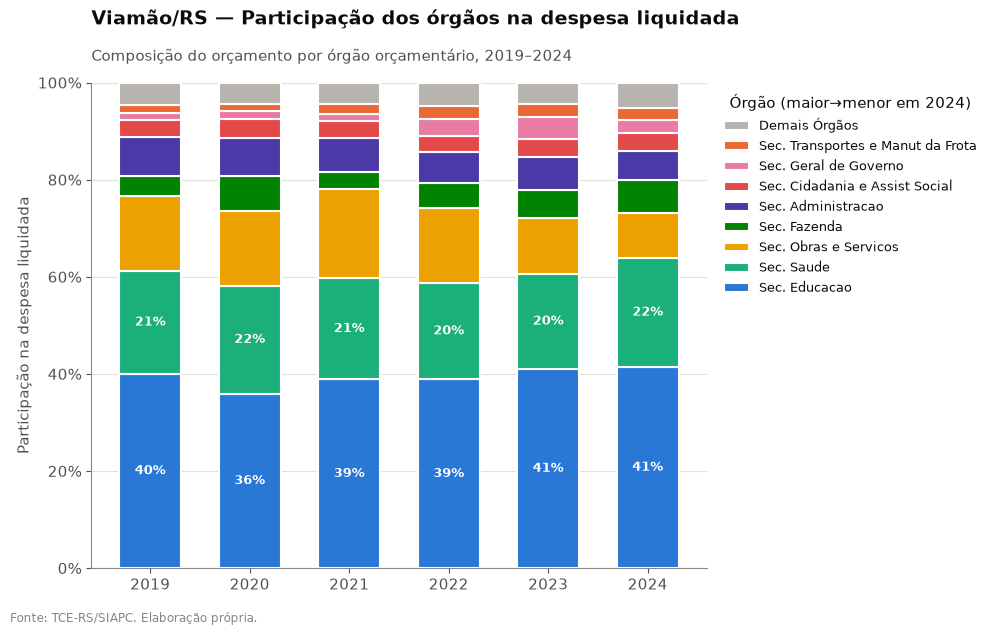

In [9]:
TOP_N = 8
ordem = piv.sort_values(ANO_BASE, ascending=False)
top = ordem.head(TOP_N)
demais = ordem.iloc[TOP_N:].sum()  # soma dos menores → 'Demais órgãos'

graf = pd.concat([top, demais.to_frame("Demais órgãos").T])
graf_part = graf.divide(graf.sum(axis=0), axis=1) * 100  # % por ano

def rotulo(nome):  # encurta nomes longos p/ legenda legível
    n = nome.title().replace("Secretaria Municipal Da ", "Sec. ")\
        .replace("Secretaria Municipal De ", "Sec. ").replace("Sec Mun Da ", "Sec. ")\
        .replace("Sec Mun De ", "Sec. ").replace("Sec Mun ", "Sec. ")\
        .replace("Sec Geral De Governo", "Sec. Geral de Governo")
    for a, b in [(" E ", " e "), (" Da ", " da "), (" De ", " de "),
                 (" Do ", " do "), (" Dos ", " dos ")]:
        n = n.replace(a, b)
    return n

cores = PALETA[:TOP_N] + [COR_DEMAIS]
fig, ax = plt.subplots(figsize=(10, 6.2))
base = pd.Series(0.0, index=graf_part.columns)
for i, orgao in enumerate(graf_part.index):
    vals = graf_part.loc[orgao].values
    ax.bar(range(len(ANOS)), vals, bottom=base.values, width=0.62,
           color=cores[i], edgecolor="white", linewidth=1.5,
           label=rotulo(orgao))
    # rótulo direto nas fatias grandes (Educação e Saúde)
    if orgao in (top.index[0], top.index[1]):
        for xi, (b, v) in enumerate(zip(base.values, vals)):
            ax.text(xi, b + v / 2, f"{v:.0f}%", ha="center", va="center",
                    color="white", fontsize=9, fontweight="bold")
    base += vals

ax.set_xticks(range(len(ANOS)))
ax.set_xticklabels(ANOS)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylabel("Participação na despesa liquidada")
ax.set_axisbelow(True)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.text(0, 1.12, "Viamão/RS — Participação dos órgãos na despesa liquidada",
        transform=ax.transAxes, fontsize=14, fontweight="bold", color=INK)
ax.text(0, 1.045, "Composição do orçamento por órgão orçamentário, 2019–2024",
        transform=ax.transAxes, fontsize=10.5, color=INK2)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.01, 1), loc="upper left",
          frameon=False, fontsize=9, title="Órgão (maior→menor em 2024)")
fig.text(0.01, -0.02, FONTE, fontsize=8.5, color=MUTED)
fig.tight_layout()
fig.subplots_adjust(top=0.85)

ARQ_PNG = DIR_GRAFICOS / "3_1_evolucao_por_orgao.png"
fig.savefig(ARQ_PNG, dpi=300, bbox_inches="tight")
print("Gráfico salvo:", ARQ_PNG.relative_to(RAIZ_PROJETO))
plt.show()

## Exportação — `output/tabelas/3_1_despesa_por_orgao.xlsx`

Uma planilha com as tabelas 3.1.A, 3.1.B e 3.1.C, o deflator IPCA e uma aba de Metadados (fonte, filtro, deflator, harmonização).

In [10]:
from datetime import datetime

ARQ_XLSX = DIR_TABELAS / "3_1_despesa_por_orgao.xlsx"
meta = pd.DataFrame([
    ("Município", "Viamão/RS (código TCE-RS 63000)"),
    ("Fonte", "TCE-RS / SIAPC — Dados Abertos (dados não auditados pelo Tribunal)"),
    ("Seção", "3.1 — Classificação institucional"),
    ("Variável", "vl_liquidacao (despesa liquidada)"),
    ("Filtro", "tipo_operacao == 'L' (Liquidação)"),
    ("Agrupamento", "órgão harmonizado por cd_orgao_orcamentario; rótulo = nome do ano mais recente"),
    ("Período", "2019 a 2024"),
    ("Valores reais", "deflator IPCA acumulado, base dez/2024"),
    ("IPCA — fonte", "IBGE/SIDRA tabela 1737, variável 69 (var. acumulada no ano)"),
    ("Inflação 2019→2024", f"{(fator[2019]-1)*100:.1f}%"),
    ("Total liquidado 2024 (R$)", round(piv[2024].sum(), 2)),
    ("Gerado por", "notebooks/31_institucional.ipynb"),
    ("Gerado em", datetime.now().isoformat(timespec="seconds")),
], columns=["campo", "valor"])

with pd.ExcelWriter(ARQ_XLSX, engine="openpyxl") as w:
    tab_a.rename_axis("orgao").to_excel(w, sheet_name="3.1.A_nominal_R$")
    tab_b.rename_axis("orgao").to_excel(w, sheet_name="3.1.B_participacao_%")
    tab_c.rename_axis("orgao").to_excel(w, sheet_name="3.1.C_variacao")
    tab_ipca.rename_axis("ano").to_excel(w, sheet_name="IPCA_deflator")
    meta.to_excel(w, sheet_name="Metadados", index=False)
print("Tabelas exportadas:", ARQ_XLSX.relative_to(RAIZ_PROJETO))
print("Abas:", "3.1.A_nominal_R$, 3.1.B_participacao_%, 3.1.C_variacao, IPCA_deflator, Metadados")

Tabelas exportadas: output\tabelas\3_1_despesa_por_orgao.xlsx
Abas: 3.1.A_nominal_R$, 3.1.B_participacao_%, 3.1.C_variacao, IPCA_deflator, Metadados


## Análise — respostas 3.1.a e 3.1.b

> Os números abaixo são lidos das tabelas acima (dados TCE-RS/SIAPC); o texto final do trabalho é redigido a partir daqui.

### 3.1.a — Quem absorve o orçamento e por quê
**Educação** e **Saúde** dominam de forma estável a despesa liquidada. Em 2024, Educação respondeu por ~**41%** (R$ 306,6 mi) e Saúde por ~**22%** (R$ 165,9 mi) — juntas, cerca de **63%** de todo o orçamento executado. Isso é típico da estrutura fiscal municipal brasileira: a Constituição vincula pisos mínimos de aplicação em **educação (25% da receita de impostos)** e **saúde (15%)**, e é no município que se concentram a rede de ensino fundamental/infantil e a atenção básica à saúde. Na sequência aparecem **Obras e Serviços** e a área-meio (**Administração**, **Fazenda**).

### 3.1.b — Evolução da participação e inversões
O topo (Educação, Saúde) não se inverte no período. As inversões relevantes estão logo abaixo: **Obras e Serviços** perde peso de forma acentuada — de ~**16%** (2019) para ~**9%** (2024) —, enquanto a **Secretaria da Fazenda** sobe de ~**4%** para ~**7%** e **ultrapassa a Administração** na disputa por 4º/5º lugar. Ver a tabela de ranking e a Tabela 3.1.C (variação real) para identificar quais órgãos cresceram **acima** da inflação (variação real > 0) e quais apenas repuseram preços. Contexto a explorar no texto: **pandemia (2020–2021)** pressionando Saúde/Assistência e **enchentes no RS (2024)** com efeito potencial sobre Obras/Urbanismo.

---
Fonte: **TCE-RS/SIAPC**. Elaboração própria.